# HOG + Colour histogram fiture builder

In [3]:
# Phase 2, Step 2 — Build dataset using HOG + Color Histogram
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import hog
from tqdm import tqdm

# ---------- CONFIG ----------
PREPROCESSED_DIR = "/home/pratyush/Desktop/DS_Project/data/preprocessed"
SPLIT_DIR        = "/home/pratyush/Desktop/DS_Project/data/splits"
OUT_DIR          = "/home/pratyush/Desktop/DS_Project/data/features"
os.makedirs(OUT_DIR, exist_ok=True)

GRID_W, GRID_H = 8, 8
TARGET_W, TARGET_H = 800, 600
CELL_W, CELL_H = TARGET_W // GRID_W, TARGET_H // GRID_H  # 100×75

# ---------- FEATURE FUNCTIONS ----------
def extract_hog_features(gray_cell):
    """Extract HOG from grayscale patch."""
    return hog(gray_cell, orientations=9,
               pixels_per_cell=(8,8),
               cells_per_block=(2,2),
               block_norm="L2-Hys",
               feature_vector=True)

def extract_color_hist(hsv_cell):
    """Compute normalized HSV histograms (8 bins/channel)."""
    hist_h = cv2.calcHist([hsv_cell],[0],None,[8],[0,180])
    hist_s = cv2.calcHist([hsv_cell],[1],None,[8],[0,256])
    hist_v = cv2.calcHist([hsv_cell],[2],None,[8],[0,256])
    color_feat = np.concatenate([hist_h, hist_s, hist_v]).ravel()
    return color_feat / (np.sum(color_feat) + 1e-6)

def extract_features_from_image(img_path, row_labels):
    """Split 800×600 image into 8×8, compute HOG+Color per cell."""
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Could not read {img_path}")
        return None, None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    X_cells, y_cells = [], []
    for r in range(GRID_H):
        for c in range(GRID_W):
            x0, y0 = c*CELL_W, r*CELL_H
            gcell = gray[y0:y0+CELL_H, x0:x0+CELL_W]
            hcell = hsv[y0:y0+CELL_H, x0:x0+CELL_W]
            hog_feat   = extract_hog_features(gcell)
            color_feat = extract_color_hist(hcell)
            feat = np.concatenate([hog_feat, color_feat])
            X_cells.append(feat)
            y_cells.append(row_labels[f"c{r*GRID_W + c + 1:02d}"])

    return np.array(X_cells), np.array(y_cells)

def build_split_features(split_name):
    csv_path = os.path.join(SPLIT_DIR, f"{split_name}_labels.csv")
    df = pd.read_csv(csv_path)
    print(f"\nBuilding HOG+Color features for {split_name} ({len(df)} images)")

    all_feats, all_labels, all_meta = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_name = row["image"]
        img_path = os.path.join(PREPROCESSED_DIR, img_name)
        X_cells, y_cells = extract_features_from_image(img_path, row)
        if X_cells is not None:
            all_feats.append(X_cells)
            all_labels.append(y_cells)
            all_meta += [(img_name, f"c{i:02d}") for i in range(1, 65)]

    X = np.vstack(all_feats)
    y = np.hstack(all_labels)

    # assemble DataFrame for CSV
    df_out = pd.DataFrame(X)
    df_out.insert(0, "cell_id", [cid for _, cid in all_meta])
    df_out.insert(0, "image", [im for im, _ in all_meta])
    df_out["label"] = y.astype(int)

    out_csv = os.path.join(OUT_DIR, f"{split_name}_hog_color_features.csv")
    df_out.to_csv(out_csv, index=False)
    print(f"✅ Saved {split_name}: {out_csv} ({df_out.shape[0]} rows)")

for split in ["train", "val", "test"]:
    build_split_features(split)



Building HOG+Color features for train (301 images)


100%|██████████| 301/301 [00:25<00:00, 11.68it/s]


✅ Saved train: /home/pratyush/Desktop/DS_Project/data/features/train_hog_color_features.csv (19264 rows)

Building HOG+Color features for val (65 images)


100%|██████████| 65/65 [00:05<00:00, 12.14it/s]


✅ Saved val: /home/pratyush/Desktop/DS_Project/data/features/val_hog_color_features.csv (4160 rows)

Building HOG+Color features for test (65 images)


100%|██████████| 65/65 [00:05<00:00, 11.95it/s]


✅ Saved test: /home/pratyush/Desktop/DS_Project/data/features/test_hog_color_features.csv (4160 rows)


# Modeling

Train: (19264, 3192),  Val: (4160, 3192),  Test: (4160, 3192)

✅ Validation Accuracy (HOG + Color): 0.7255
              precision    recall  f1-score   support

           0      0.730     0.936     0.820      2781
           1      0.699     0.302     0.421      1379

    accuracy                          0.725      4160
   macro avg      0.715     0.619     0.621      4160
weighted avg      0.720     0.725     0.688      4160



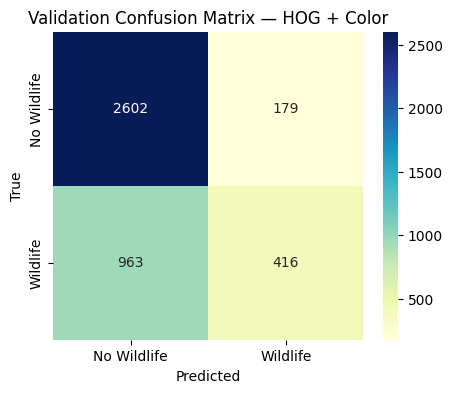

🧪 Test Accuracy: 0.7188

Test Set Performance:
              precision    recall  f1-score   support

           0      0.717     0.939     0.813      2716
           1      0.727     0.304     0.429      1444

    accuracy                          0.719      4160
   macro avg      0.722     0.622     0.621      4160
weighted avg      0.721     0.719     0.680      4160



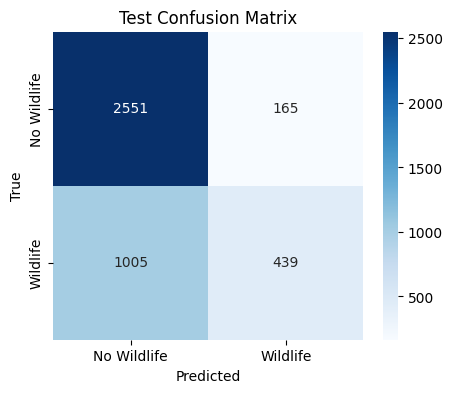

In [4]:
# Phase 3 — Model for HOG + Color Features
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- LOAD DATA ----------
FEATURE_DIR = "/home/pratyush/Desktop/DS_Project/data/features"

df_train = pd.read_csv(f"{FEATURE_DIR}/train_hog_color_features.csv")
df_val   = pd.read_csv(f"{FEATURE_DIR}/val_hog_color_features.csv")
df_test  = pd.read_csv(f"{FEATURE_DIR}/test_hog_color_features.csv")

# Split features / labels
X_train = df_train.drop(["image","cell_id","label"], axis=1).values
y_train = df_train["label"].values
X_val   = df_val.drop(["image","cell_id","label"], axis=1).values
y_val   = df_val["label"].values
X_test  = df_test.drop(["image","cell_id","label"], axis=1).values
y_test  = df_test["label"].values

print(f"Train: {X_train.shape},  Val: {X_val.shape},  Test: {X_test.shape}")

# ---------- TRAIN RANDOM FOREST ----------
rf = RandomForestClassifier(
    n_estimators=200,       # more trees = smoother boundaries
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced_subsample",  # helps if 0/1 imbalance exists
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

# ---------- VALIDATION ----------
y_pred_val = rf.predict(X_val)
val_acc = accuracy_score(y_val, y_pred_val)
print(f"\n✅ Validation Accuracy (HOG + Color): {val_acc:.4f}")
print(classification_report(y_val, y_pred_val, digits=3))

# Confusion matrix visualization
cm_val = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(5,4))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['No Wildlife','Wildlife'],
            yticklabels=['No Wildlife','Wildlife'])
plt.title("Validation Confusion Matrix — HOG + Color")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---------- TEST SET ----------
y_pred_test = rf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)
print(f"🧪 Test Accuracy: {test_acc:.4f}")

# Optional classification report for test set
print("\nTest Set Performance:")
print(classification_report(y_test, y_pred_test, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Wildlife','Wildlife'], yticklabels=['No Wildlife','Wildlife'])
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Observation:
Adding color histograms to HOG features improved overall classification accuracy by ~2%, mainly by reducing false positives in background regions. However, the model’s recall for wildlife decreased, indicating it became more conservative in detecting animals, possibly due to reliance on color uniformity.

Inference:
While HOG captures structural shape, color adds contextual background separation. The next logical feature to integrate is GLCM texture, which should help recover recall by capturing surface variation patterns even when color cues are weak.